<a href="https://colab.research.google.com/github/AfrinHossai/cs171-police-call-forecasting/blob/main/04_baseline_and_tree_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [137]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [138]:
# Import statements
from sklearn.linear_model import LinearRegression, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from time import perf_counter
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score
from great_tables import GT, style, loc
from IPython.display import display
from sklearn.model_selection import GridSearchCV
from sklearn.inspection import permutation_importance
from sklearn.model_selection import LearningCurveDisplay

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import os

In [139]:
# Sources referenced:

# https://www.geeksforgeeks.org/machine-learning/building-and-implementing-decision-tree-classifiers-with-scikit-learn-a-comprehensive-guide/
# https://www.datacamp.com/tutorial/random-forest-regression
# https://matplotlib.org/stable/gallery/color/named_colors.html
# https://www.youtube.com/watch?v=xl6KAAVytEk - Elastic Net Regression Tutorial
# https://numpy.org/doc/stable/reference/random/generated/numpy.random.choice.html
# https://stackoverflow.com/questions/48791709/how-to-plot-a-heat-map-on-pivot-table-after-grid-search - heatmap tutorial
# https://scikit-learn.org/stable/auto_examples/ensemble/plot_forest_importances.html
# https://scikit-learn.org/stable/auto_examples/tree/plot_tree_regression.html
# https://stackoverflow.com/questions/19482970/get-a-list-from-pandas-dataframe-column-headers
# https://scikit-learn.org/stable/auto_examples/tree/plot_tree_regression.html#decision-tree-regression-with-multi-output-targets
# https://scikit-learn.org/stable/auto_examples/model_selection/plot_learning_curve.html

In [140]:
# Goal: Create simple baseline models

# Step 1: Obtain the train dataset
processed_folder = "/content/drive/MyDrive/CS171_Police_Call_Project/data_processed"

train_scaled_df = pd.read_csv(
    f"{processed_folder}/train_scaled.csv"
)

validation_scaled_df = pd.read_csv(
    f"{processed_folder}/validation_scaled.csv"
)

# Step 2: Create the baseline model : a simple mean predictor
total_calls = train_scaled_df['NEXT_HOUR_CALLS'].sum()
num_hours = len(train_scaled_df)

mean_hourly_call_count = total_calls / num_hours
print(f"Mean hourly count: Approximately {mean_hourly_call_count:.4} calls are received every hour.")

# Step 3: Create a new column that represents a persistence forecast (uses the previous hour's count)
train_scaled_df['PERSISTENCE_PREDICTION'] = train_scaled_df['NEXT_HOUR_CALLS'].shift(1)
validation_scaled_df['PERSISTENCE_PREDICTION'] = validation_scaled_df['NEXT_HOUR_CALLS'].shift(1)

train_scaled_df.head()

Mean hourly count: Approximately 30.78 calls are received every hour.


,HOUR,NEXT_TIMESTAMP,TARGET_HOUR,TARGET_DAY_OF_WEEK,TARGET_MONTH,TARGET_IS_WEEKEND,HOUR_SIN,HOUR_COS,DAY_OF_WEEK_SIN,DAY_OF_WEEK_COS,...,CURRENT_CALLTYPE_THEFT_COUNT,CURRENT_CALLTYPE_RECKLESS_DRIVING_COUNT,CURRENT_CALLTYPE_VEHICLE_ACCIDENT_PROPERTY_DAMAGE_COUNT,CURRENT_CALLTYPE_PEDESTRIAN_STOP_COUNT,CURRENT_CALLTYPE_TRAFFIC_HAZARD_COUNT,CURRENT_CALLTYPE_MEET_THE_CITIZEN_COUNT,CURRENT_CALLTYPE_RECOVERED_STOLEN_VEHICLE_COUNT,CURRENT_CALLTYPE_OTHER_COUNT,NEXT_HOUR_CALLS,PERSISTENCE_PREDICTION
0,2024-01-07 23:00:00,2024-01-08 00:00:00,-1.661609,-1.49438,-1.572991,-0.630874,0.000095,1.414426,-0.00194,1.409718,...,-0.686278,0.392031,0.533891,0.66914,-0.508273,-0.641627,2.318661,-0.956892,34,NaN
1,2024-01-08 00:00:00,2024-01-08 01:00:00,-1.517137,-1.49438,-1.572991,-0.630874,0.366108,1.366237,-0.00194,1.409718,...,-0.686278,1.476900,-0.669392,0.66914,-0.508273,-0.641627,-0.577590,-0.715549,21,34.0
2,2024-01-08 01:00:00,2024-01-08 02:00:00,-1.372666,-1.49438,-1.572991,-0.630874,0.707178,1.224951,-0.00194,1.409718,...,-0.686278,0.392031,-0.669392,0.66914,-0.508273,-0.641627,-0.577590,-1.439577,19,21.0
3,2024-01-08 02:00:00,2024-01-08 03:00:00,-1.228194,-1.49438,-1.572991,-0.630874,1.000062,1.000199,-0.00194,1.409718,...,-0.686278,-0.692839,-0.669392,-0.59257,0.579574,-0.641627,2.318661,-0.715549,12,19.0
4,2024-01-08 03:00:00,2024-01-08 04:00:00,-1.083722,-1.49438,-1.572991,-0.630874,1.224799,0.707296,-0.00194,1.409718,...,-0.686278,-0.692839,-0.669392,0.66914,-0.508273,-0.641627,-0.577590,-1.439577,16,12.0


In [141]:
# Split the train and validation datasets
X_train = train_scaled_df.drop(columns=['HOUR', 'NEXT_TIMESTAMP', 'NEXT_HOUR_CALLS', 'PERSISTENCE_PREDICTION'])
y_train = train_scaled_df['NEXT_HOUR_CALLS']

X_val = validation_scaled_df.drop(columns=['HOUR', 'NEXT_TIMESTAMP', 'NEXT_HOUR_CALLS', 'PERSISTENCE_PREDICTION'])
y_val = validation_scaled_df['NEXT_HOUR_CALLS']

feature_names = X_train.columns

In [142]:
# Compute MAE, MSE, RMSE, and R^2 for different models
def compute_metrics(y_true, y_pred):
  mae = round(mean_absolute_error(y_true, y_pred), 3)
  mse = round(mean_squared_error(y_true, y_pred), 3)
  rmse = round(root_mean_squared_error(y_true, y_pred), 3)
  r2 = round(r2_score(y_true, y_pred), 3)

  return mae, mse, rmse, r2

# Save matplotlib figures to Google Drive
def save_figure(fig_name):
  plt.savefig(f"/content/drive/MyDrive/Results/{fig_name}.png")

# Save model predictions to Google Drive
def save_results(df, model_type, file_name):
  path = os.path.join("/content/drive/MyDrive/CS171_Police_Call_Project/models", model_type, file_name)
  df.to_csv(path, index=False)

In [143]:
# Display DataFrames as tables
def display_table(df, title, subtitle=None):
  return (
      GT(df)
      .tab_header(
          title=title,
          subtitle=subtitle
      )

      .tab_style(
          style=style.fill(color="darkkhaki"),
          locations=loc.column_labels()
      )

      .tab_style(
          style=style.text(color="black",weight="bold"),
          locations=loc.title(),
      )
  )

In [144]:
# Declare variables for selecting random rows
np.random.seed(42)
size = int(0.3 * len(y_val))
sample_indices = np.random.choice(np.arange(len(y_val)), size, replace=False)

GT(_tbl_data=   Training Time (secs)    MAE     MSE   RMSE  R^2 score
0                  0.03  4.985  41.295  6.426      0.668, _body=<great_tables._gt_data.Body object at 0x7cf339659cd0>, _boxhead=Boxhead([ColInfo(var='Training Time (secs)', type=<ColInfoTypeEnum.default: 1>, column_label='Training Time (secs)', column_align='right', column_width=None), ColInfo(var='MAE', type=<ColInfoTypeEnum.default: 1>, column_label='MAE', column_align='right', column_width=None), ColInfo(var='MSE', type=<ColInfoTypeEnum.default: 1>, column_label='MSE', column_align='right', column_width=None), ColInfo(var='RMSE', type=<ColInfoTypeEnum.default: 1>, column_label='RMSE', column_align='right', column_width=None), ColInfo(var='R^2 score', type=<ColInfoTypeEnum.default: 1>, column_label='R^2 score', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7cf340352840>, _spanners=Spanners([]), _heading=Heading(title='Linear Regression Metrics', subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7cf345105790>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7cf3402c8980>, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='Training Time (secs)', rownum=None, colnum=None, styles=[CellStyleFill(color='darkkhaki')]), StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='MAE', rownum=None, colnum=None, styles=[CellStyleFill(color='darkkhaki')]), StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='MSE', rownum=None, colnum=None, styles=[CellStyleFill(color='darkkhaki')]), StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='RMSE', rownum=None, colnum=None, styles=[CellStyleFill(color='darkkhaki')]), StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='R^2 score', rownum=None, colnum=None, styles=[CellStyleFill(color='darkkhaki')]), StyleInfo(locname=LocTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color='black', font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)])], _locale=<great_tables._gt_data.Locale object at 0x7cf345105520>, _formats=[], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True

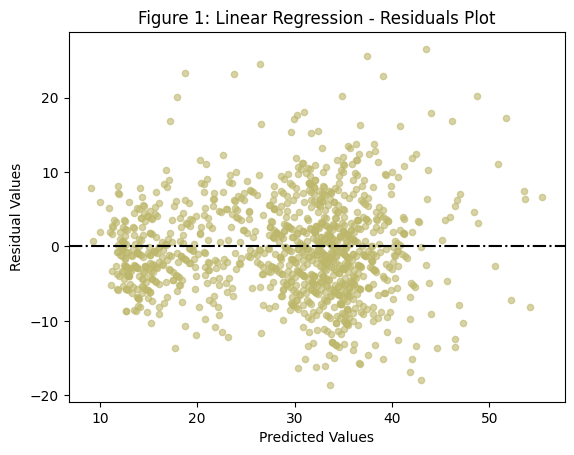

In [145]:
# Goal: Train a simple linear regression model

# Step 1: Fit the model
lr_start_time = perf_counter()
lr = LinearRegression().fit(X_train, y_train)
lr_training_time = round(perf_counter() - lr_start_time, 2)

# Step 2: Predict on the validation dataset
lr_y_pred = lr.predict(X_val)

# Step 3: Create a table for the predicted vs actual values
lr_idx = sample_indices

p_10 = lr_y_pred[lr_idx]
a_10 = y_val.iloc[lr_idx]

lr_results_df = pd.DataFrame({'Pred. Values': np.round(p_10, 2), 'Actual Values': a_10})

# Step 4: Create a residuals scatter plot
lr_residuals = y_val - lr_y_pred

np.random.seed(42)
plt.scatter(lr_y_pred[lr_idx], lr_residuals.iloc[lr_idx], marker='o', c='darkkhaki', s=20, alpha=0.6)
plt.axhline(y=0, color='black', linestyle='-.')

plt.xlabel("Predicted Values")
plt.ylabel("Residual Values")
plt.title("Figure 1: Linear Regression - Residuals Plot")

# Step 5: Create the learned equation
features = list(X_train.columns)

y = f"{round(lr.intercept_, 3)}"
for coef, feature in zip(lr.coef_, features):
  y += f" + {round(coef, 3)}*{feature}"

# Step 6: Create table for metrics
lr_mae, lr_mse, lr_rmse, lr_r2 = compute_metrics(y_val, lr_y_pred)

lr_metrics_df = pd.DataFrame({'Training Time (secs)': [lr_training_time], 'MAE': [lr_mae],
                      'MSE': [lr_mse], 'RMSE': [lr_rmse], 'R^2 score': [lr_r2]})

lr_metrics_table = display_table(
    lr_metrics_df,
    "Linear Regression Metrics",
)

display(lr_metrics_table)

# Step 9: Save results/figures
save_results(lr_results_df, "LinearRegression", "linear_regression_predicted_v_actual.csv")
save_figure("linear_regression_plot")


GT(_tbl_data=                              Model type  Training time (secs)    MAE     MSE  \
0                               Model #1                  0.03  5.319  45.261   
1  Model #2 (with hyperparameter tuning)                 20.73  4.985  41.288   

    RMSE  R^2 score  
0  6.728      0.636  
1  6.426      0.668  , _body=<great_tables._gt_data.Body object at 0x7cf340849eb0>, _boxhead=Boxhead([ColInfo(var='Model type', type=<ColInfoTypeEnum.default: 1>, column_label='Model type', column_align='left', column_width=None), ColInfo(var='Training time (secs)', type=<ColInfoTypeEnum.default: 1>, column_label='Training time (secs)', column_align='right', column_width=None), ColInfo(var='MAE', type=<ColInfoTypeEnum.default: 1>, column_label='MAE', column_align='right', column_width=None), ColInfo(var='MSE', type=<ColInfoTypeEnum.default: 1>, column_label='MSE', column_align='right', column_width=None), ColInfo(var='RMSE', type=<ColInfoTypeEnum.default: 1>, column_label='RMSE', column_align='right', column_width=None), ColInfo(var='R^2 score', type=<ColInfoTypeEnum.default: 1>, column_label='R^2 score', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7cf3402e0470>, _spanners=Spanners([]), _heading=Heading(title='ElasticNet Metrics', subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7cf3404e5d00>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7cf345104ec0>, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='Model type', rownum=None, colnum=None, styles=[CellStyleFill(color='darkkhaki')]), StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='Training time (secs)', rownum=None, colnum=None, styles=[CellStyleFill(color='darkkhaki')]), StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='MAE', rownum=None, colnum=None, styles=[CellStyleFill(color='darkkhaki')]), StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='MSE', rownum=None, colnum=None, styles=[CellStyleFill(color='darkkhaki')]), StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='RMSE', rownum=None, colnum=None, styles=[CellStyleFill(color='darkkhaki')]), StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='R^2 score', rownum=None, colnum=None, styles=[CellStyleFill(color='darkkhaki')]), StyleInfo(locname=LocTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color='black', font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)])], _locale=<great_tables._gt_data.Locale object at 0x7cf3404e5370>, _formats=[], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=Tr

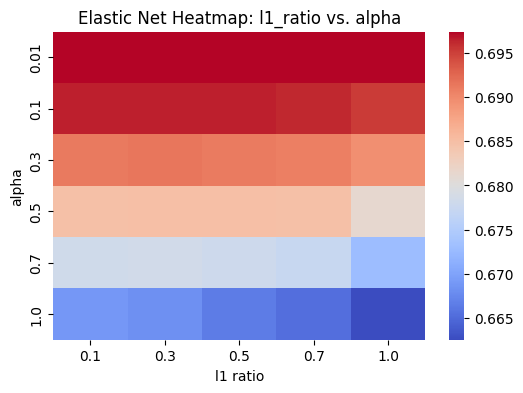

In [146]:
# Goal : Apply Elastic Net regularization

en_c1 = ['Model #1', 'Model #2 (with hyperparameter tuning)']
en_c2, en_c3, en_c4, en_c5, en_c6 = ([] for i in range(5))

# Step 1: Fit the model
regr_start_time = perf_counter()
regr = ElasticNet().fit(X_train, y_train)
regr_training_time = round(perf_counter() - regr_start_time, 2)
en_c2.append(regr_training_time)

# Step 2: Predict on the validation dataset
regr_predictions = regr.predict(X_val)

# Step 3: Hyperparameter tuning
param_grid = {
    'alpha': [0.01, 0.1, 0.3, 0.5, 0.7, 1.0],
    'l1_ratio': [0.1, 0.3, 0.5, 0.7, 1.0]
}

# Step 4: Fit a new model
elastic_net_cv = GridSearchCV(regr, param_grid)

new_regr_start_time = perf_counter()
elastic_net_cv.fit(X_train, y_train)
new_regr_training_time = round(perf_counter() - new_regr_start_time, 2)
en_c2.append(new_regr_training_time)

new_regr_pred = elastic_net_cv.predict(X_val)

# Step 5: Compute metrics for summary table
regr_mae, regr_mse, regr_rmse, regr_r2 = compute_metrics(y_val, regr_predictions)
new_regr_mae, new_regr_mse, new_regr_rmse, new_regr_r2 = compute_metrics(y_val, new_regr_pred)

en_c3.append(regr_mae)
en_c4.append(regr_mse)
en_c5.append(regr_rmse)
en_c6.append(regr_r2)

en_c3.append(new_regr_mae)
en_c4.append(new_regr_mse)
en_c5.append(new_regr_rmse)
en_c6.append(new_regr_r2)

# Step 6: Compare the predicted and actual values
elastic_idx = sample_indices

elastic_c1 = np.round(regr_predictions[elastic_idx], 2)
elastic_c2 = np.round(new_regr_pred[elastic_idx], 2)
elastic_c3 = y_val.iloc[elastic_idx]

elastic_df = pd.DataFrame({'Pred. Values': elastic_c1, 'New Pred. Values': elastic_c2, 'Actual Values': elastic_c3})

# Step 7: Create heatmap comparing alpha and l1_ratio
heatmap = pd.pivot_table(pd.DataFrame(elastic_net_cv.cv_results_),
    values='mean_test_score', index='param_alpha', columns='param_l1_ratio')

plt.figure(figsize=(6, 4))
ax = sns.heatmap(heatmap, cmap='coolwarm')

plt.title("Elastic Net Heatmap: l1_ratio vs. alpha")
plt.xlabel("l1 ratio")
plt.ylabel("alpha")

save_figure("elastic_net_heatmap")


# Step 8: Create table for metrics
elastic_metrics = pd.DataFrame({'Model type': en_c1, 'Training time (secs)': en_c2,
                                'MAE': en_c3, 'MSE': en_c4, 'RMSE': en_c5, 'R^2 score': en_c6})

elastic_metrics_table = display_table(
    elastic_metrics,
    "ElasticNet Metrics",
)

display(elastic_metrics_table)

# Step 9: Save results/figures
save_results(elastic_df, "ElasticNet (Regularization)", "elastic_net_predicted_v_actual.csv")
save_figure("elastic_net_heatmap")


In [147]:
# Goal: Train decision tree models

dt_training_times , dt_mae_list, dt_mse_list, dt_rmse_list, dt_r2_list = ([] for i in range(5))

# Step 1: Fit a decision tree regressor
dt_regressor = DecisionTreeRegressor()

dt_start_time = perf_counter()
dt_regressor.fit(X_train, y_train)
dt_training_time = round(perf_counter() - dt_start_time, 3)
dt_training_times.append(dt_training_time)

y_pred = dt_regressor.predict(X_val)

# Step 2: Compute metrics for summary table
dt_mae, dt_mse, dt_rmse, dt_r2 = compute_metrics(y_val, y_pred)

dt_mae_list.append(dt_mae)
dt_mse_list.append(dt_mse)
dt_rmse_list.append(dt_rmse)
dt_r2_list.append(dt_r2)

In [148]:
# Step 3: Tune max_depth parameter (Decision Tree Regressor)
max_depth_list = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
max_depth_mae_vals, max_depth_mse_vals, max_depth_rmse_vals, max_depth_r2_vals = ([] for i in range(4))
max_depth_rmse = float("inf")
final_max_depth = 0

for depth in max_depth_list:
  regressor = DecisionTreeRegressor(max_depth=depth, random_state=42, min_samples_split=2, min_samples_leaf=1)
  regressor.fit(X_train, y_train)

  y_prediction = regressor.predict(X_val)

  mae_val, mse_val, rmse_val, r2_val = compute_metrics(y_val, y_prediction)

  max_depth_mae_vals.append(mae_val)
  max_depth_mse_vals.append(mse_val)
  max_depth_rmse_vals.append(rmse_val)
  max_depth_r2_vals.append(r2_val)

  if (rmse_val < max_depth_rmse):
    max_depth_rmse = rmse_val
    final_max_depth = depth

# Construct a table for max_depth tuning performance
max_depth_df = pd.DataFrame({'max_depth': max_depth_list, 'MAE': max_depth_mae_vals, 'MSE': max_depth_mse_vals,
                             'RMSE': max_depth_rmse_vals, 'R^2 score': max_depth_r2_vals})

max_depth_table = display_table(
    max_depth_df,
    title="Decision Tree Regression: Hyperparameter #1 Tuning Results",
    subtitle="max_depth"
)

display(max_depth_table)

GT(_tbl_data=   max_depth    MAE     MSE   RMSE  R^2 score
0          1  6.971  78.606  8.866      0.368
1          2  6.442  68.108  8.253      0.453
2          3  6.024  60.236  7.761      0.516
3          4  5.697  53.973  7.347      0.566
4          5  5.471  49.481  7.034      0.602
5          6  5.284  46.863  6.846      0.623
6          7  5.235  45.686  6.759      0.633
7          8  5.222  45.680  6.759      0.633
8          9  5.320  48.377  6.955      0.611
9         10  5.417  49.694  7.049      0.601, _body=<great_tables._gt_data.Body object at 0x7cf34923d3d0>, _boxhead=Boxhead([ColInfo(var='max_depth', type=<ColInfoTypeEnum.default: 1>, column_label='max_depth', column_align='right', column_width=None), ColInfo(var='MAE', type=<ColInfoTypeEnum.default: 1>, column_label='MAE', column_align='right', column_width=None), ColInfo(var='MSE', type=<ColInfoTypeEnum.default: 1>, column_label='MSE', column_align='right', column_width=None), ColInfo(var='RMSE', type=<ColInfoTypeEnum.default: 1>, column_label='RMSE', column_align='right', column_width=None), ColInfo(var='R^2 score', type=<ColInfoTypeEnum.default: 1>, column_label='R^2 score', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7cf3451a3500>, _spanners=Spanners([]), _heading=Heading(title='Decision Tree Regression: Hyperparameter #1 Tuning Results', subtitle='max_depth', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7cf34067c050>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7cf34067f0b0>, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='max_depth', rownum=None, colnum=None, styles=[CellStyleFill(color='darkkhaki')]), StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='MAE', rownum=None, colnum=None, styles=[CellStyleFill(color='darkkhaki')]), StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='MSE', rownum=None, colnum=None, styles=[CellStyleFill(color='darkkhaki')]), StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='RMSE', rownum=None, colnum=None, styles=[CellStyleFill(color='darkkhaki')]), StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='R^2 score', rownum=None, colnum=None, styles=[CellStyleFill(color='darkkhaki')]), StyleInfo(locname=LocTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color='black', font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)])], _locale=<great_tables._gt_data.Locale object at 0x7cf34067f920>, _formats=[], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=Opti

In [149]:
# Step 4: Tune the min # of samples required for an internal node split
min_samples_list = [10, 20, 25, 50, 75, 100, 125, 250]
min_samples_mae_vals, min_samples_mse_vals, min_samples_rmse_vals, min_samples_r2_vals = ([] for i in range(4))
min_samples_rmse = float('inf')
final_min_samples = 0

for sample_size in min_samples_list:
  regressor = DecisionTreeRegressor(random_state=42, min_samples_split=sample_size, min_samples_leaf=1)
  regressor.fit(X_train, y_train)

  y_prediction = regressor.predict(X_val)

  mae_val, mse_val, rmse_val, r2_val = compute_metrics(y_val, y_prediction)

  min_samples_mae_vals.append(mae_val)
  min_samples_mse_vals.append(mse_val)
  min_samples_rmse_vals.append(rmse_val)
  min_samples_r2_vals.append(r2_val)

  if (rmse_val < min_samples_rmse ):
    min_samples_rmse = rmse_val
    final_min_samples = sample_size

# Construct a table for min_samples_split
min_samples_df = pd.DataFrame({'min_samples_split': min_samples_list, 'MAE':min_samples_mae_vals, 'MSE': min_samples_mse_vals,
                               'RMSE': min_samples_rmse_vals, 'R^2 score': min_samples_r2_vals})

min_samples_table = display_table(
    min_samples_df,
    title="Decision Tree Regression: Hyperparameter #2 Tuning Results",
    subtitle="min_samples_split"
)

display(min_samples_table)

GT(_tbl_data=   min_samples_split    MAE     MSE   RMSE  R^2 score
0                 10  6.608  73.076  8.548      0.413
1                 20  6.134  63.547  7.972      0.489
2                 25  5.967  60.453  7.775      0.514
3                 50  5.546  51.544  7.179      0.586
4                 75  5.403  48.755  6.983      0.608
5                100  5.346  47.359  6.882      0.619
6                125  5.304  46.835  6.844      0.624
7                250  5.203  45.219  6.725      0.637, _body=<great_tables._gt_data.Body object at 0x7cf345129d60>, _boxhead=Boxhead([ColInfo(var='min_samples_split', type=<ColInfoTypeEnum.default: 1>, column_label='min_samples_split', column_align='right', column_width=None), ColInfo(var='MAE', type=<ColInfoTypeEnum.default: 1>, column_label='MAE', column_align='right', column_width=None), ColInfo(var='MSE', type=<ColInfoTypeEnum.default: 1>, column_label='MSE', column_align='right', column_width=None), ColInfo(var='RMSE', type=<ColInfoTypeEnum.default: 1>, column_label='RMSE', column_align='right', column_width=None), ColInfo(var='R^2 score', type=<ColInfoTypeEnum.default: 1>, column_label='R^2 score', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7cf3402f9640>, _spanners=Spanners([]), _heading=Heading(title='Decision Tree Regression: Hyperparameter #2 Tuning Results', subtitle='min_samples_split', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7cf34067dac0>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7cf34067e4b0>, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='min_samples_split', rownum=None, colnum=None, styles=[CellStyleFill(color='darkkhaki')]), StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='MAE', rownum=None, colnum=None, styles=[CellStyleFill(color='darkkhaki')]), StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='MSE', rownum=None, colnum=None, styles=[CellStyleFill(color='darkkhaki')]), StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='RMSE', rownum=None, colnum=None, styles=[CellStyleFill(color='darkkhaki')]), StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='R^2 score', rownum=None, colnum=None, styles=[CellStyleFill(color='darkkhaki')]), StyleInfo(locname=LocTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color='black', font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)])], _locale=<great_tables._gt_data.Locale object at 0x7cf34067cb00>, _formats=[], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_fon

In [150]:
# Step 5: Tune the min # of samples a leaf node requires
leaf_sizes_list = [1, 5, 10, 15, 25, 50, 75, 100, 125]
leaf_samples_mae_vals, leaf_samples_mse_vals, leaf_samples_rmse_vals, leaf_samples_r2_vals = ([] for i in range(4))
leaf_samples_rmse = float('inf')
final_leaf_samples = 0

for leaf_size in leaf_sizes_list:
  regressor = DecisionTreeRegressor(random_state=42, min_samples_leaf=leaf_size)
  regressor.fit(X_train, y_train)

  y_prediction = regressor.predict(X_val)

  mae_val, mse_val, rmse_val, r2_val = compute_metrics(y_val, y_prediction)

  leaf_samples_mae_vals.append(mae_val)
  leaf_samples_mse_vals.append(mse_val)
  leaf_samples_rmse_vals.append(rmse_val)
  leaf_samples_r2_vals.append(r2_val)

  if (rmse_val < leaf_samples_rmse):
    leaf_samples_rmse = rmse_val
    final_leaf_samples = leaf_size

# Construct a table for min_samples_split
leaf_samples_df = pd.DataFrame({'min_samples_leaf': leaf_sizes_list, 'MAE': leaf_samples_mae_vals, 'MSE': leaf_samples_mse_vals,
                                'RMSE': leaf_samples_rmse_vals, 'R^2 score': leaf_samples_r2_vals})

leaf_samples_table = display_table(
    leaf_samples_df,
    "Decision Tree Regression: Hyperparameter #3 Tuning Metrics",
    "leaf_samples_split"
)

display(leaf_samples_table)

GT(_tbl_data=   min_samples_leaf    MAE     MSE   RMSE  R^2 score
0                 1  6.805  78.116  8.838      0.372
1                 5  6.138  60.986  7.809      0.510
2                10  5.698  52.870  7.271      0.575
3                15  5.342  47.449  6.888      0.619
4                25  5.151  44.524  6.673      0.642
5                50  5.053  42.804  6.542      0.656
6                75  5.098  43.031  6.560      0.654
7               100  5.101  43.367  6.585      0.651
8               125  5.188  45.124  6.717      0.637, _body=<great_tables._gt_data.Body object at 0x7cf380215520>, _boxhead=Boxhead([ColInfo(var='min_samples_leaf', type=<ColInfoTypeEnum.default: 1>, column_label='min_samples_leaf', column_align='right', column_width=None), ColInfo(var='MAE', type=<ColInfoTypeEnum.default: 1>, column_label='MAE', column_align='right', column_width=None), ColInfo(var='MSE', type=<ColInfoTypeEnum.default: 1>, column_label='MSE', column_align='right', column_width=None), ColInfo(var='RMSE', type=<ColInfoTypeEnum.default: 1>, column_label='RMSE', column_align='right', column_width=None), ColInfo(var='R^2 score', type=<ColInfoTypeEnum.default: 1>, column_label='R^2 score', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7cf344759550>, _spanners=Spanners([]), _heading=Heading(title='Decision Tree Regression: Hyperparameter #3 Tuning Metrics', subtitle='leaf_samples_split', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7cf3451a2960>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7cf342073680>, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='min_samples_leaf', rownum=None, colnum=None, styles=[CellStyleFill(color='darkkhaki')]), StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='MAE', rownum=None, colnum=None, styles=[CellStyleFill(color='darkkhaki')]), StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='MSE', rownum=None, colnum=None, styles=[CellStyleFill(color='darkkhaki')]), StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='RMSE', rownum=None, colnum=None, styles=[CellStyleFill(color='darkkhaki')]), StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='R^2 score', rownum=None, colnum=None, styles=[CellStyleFill(color='darkkhaki')]), StyleInfo(locname=LocTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color='black', font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)])], _locale=<great_tables._gt_data.Locale object at 0x7cf3420734a0>, _formats=[], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table'

GT(_tbl_data=                              Model Type  Training Time (secs)    MAE     MSE  \
0                               Model #1                 0.544  6.911  80.123   
1  Model #2 (with hyperparameter tuning)                 0.136  5.182  44.598   

    RMSE  R^2 score  
0  8.951      0.356  
1  6.678      0.642  , _body=<great_tables._gt_data.Body object at 0x7cf3420f9df0>, _boxhead=Boxhead([ColInfo(var='Model Type', type=<ColInfoTypeEnum.default: 1>, column_label='Model Type', column_align='left', column_width=None), ColInfo(var='Training Time (secs)', type=<ColInfoTypeEnum.default: 1>, column_label='Training Time (secs)', column_align='right', column_width=None), ColInfo(var='MAE', type=<ColInfoTypeEnum.default: 1>, column_label='MAE', column_align='right', column_width=None), ColInfo(var='MSE', type=<ColInfoTypeEnum.default: 1>, column_label='MSE', column_align='right', column_width=None), ColInfo(var='RMSE', type=<ColInfoTypeEnum.default: 1>, column_label='RMSE', column_align='right', column_width=None), ColInfo(var='R^2 score', type=<ColInfoTypeEnum.default: 1>, column_label='R^2 score', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7cf34067f590>, _spanners=Spanners([]), _heading=Heading(title='Decision Tree Regression Metrics', subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7cf344f0b800>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7cf344f08e00>, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='Model Type', rownum=None, colnum=None, styles=[CellStyleFill(color='darkkhaki')]), StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='Training Time (secs)', rownum=None, colnum=None, styles=[CellStyleFill(color='darkkhaki')]), StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='MAE', rownum=None, colnum=None, styles=[CellStyleFill(color='darkkhaki')]), StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='MSE', rownum=None, colnum=None, styles=[CellStyleFill(color='darkkhaki')]), StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='RMSE', rownum=None, colnum=None, styles=[CellStyleFill(color='darkkhaki')]), StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='R^2 score', rownum=None, colnum=None, styles=[CellStyleFill(color='darkkhaki')]), StyleInfo(locname=LocTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color='black', font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)])], _locale=<great_tables._gt_data.Locale object at 0x7cf342089220>, _formats=[], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=Optio

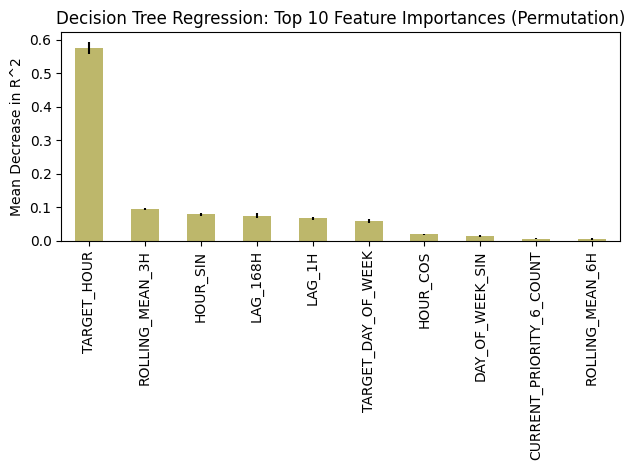

In [151]:
# Step 6: Build a new decision tree model after hyperparameter tuning
final_dt_regressor = DecisionTreeRegressor(max_depth=final_max_depth, min_samples_split=final_min_samples, min_samples_leaf=final_leaf_samples)

new_dt_start_time = perf_counter()
final_dt_regressor.fit(X_train, y_train)
new_dt_training_time = round(perf_counter() - new_dt_start_time, 3)
dt_training_times.append(new_dt_training_time)

new_y_pred = final_dt_regressor.predict(X_val)

# Compute metrics (after hyperparameter tuning)
new_dt_mae, new_dt_mse, new_dt_rmse, new_dt_r2 = compute_metrics(y_val, new_y_pred)

dt_mae_list.append(new_dt_mae)
dt_mse_list.append(new_dt_mse)
dt_rmse_list.append(new_dt_rmse)
dt_r2_list.append(new_dt_r2)

# Step 7: Create a table comparing the predicted vs actual values
dt_idx = sample_indices

dt_c1 = np.round(y_pred[dt_idx], 2)
dt_c2 = np.round(new_y_pred[dt_idx], 2)
dt_c3 = y_val.iloc[dt_idx]

dt_df = pd.DataFrame({'Pred. Values': dt_c1, 'New Pred. Values': dt_c2, 'Actual Values': dt_c3})

# Step 8: Create a feature importance bar chart
dt_result = permutation_importance(
    final_dt_regressor, X_val, y_val, scoring="r2", n_repeats=10, random_state=42, n_jobs=2
)

tree_importances = pd.Series(dt_result.importances_mean, index=feature_names)
tree_std = pd.Series(dt_result.importances_std, index=feature_names)
tree_top10 = tree_importances.sort_values(ascending=False).head(10)

fig, ax = plt.subplots()
tree_top10.plot.bar(yerr=tree_std[tree_top10.index], ax=ax, color='darkkhaki')

ax.set_title("Decision Tree Regression: Top 10 Feature Importances (Permutation)")
ax.set_ylabel("Mean Decrease in R^2")
fig.tight_layout()

save_figure("decision_tree_feature_importance")

# Step 9: Create table for metrics
dt_models = ['Model #1', 'Model #2 (with hyperparameter tuning)']
dt_metrics = pd.DataFrame({'Model Type': dt_models, 'Training Time (secs)': dt_training_times,
                                'MAE': dt_mae_list, 'MSE': dt_mse_list, 'RMSE': dt_rmse_list, 'R^2 score': dt_r2_list})

decision_tree_table = display_table(
    dt_metrics,
    "Decision Tree Regression Metrics",
)

display(decision_tree_table)

# Step 10: Save results/figures
save_results(dt_df, "DecisionTree", "decision_tree_predicted_v_actual.csv")


In [152]:
# Goal: Train random forest models

rf_training_times, rf_mae_list, rf_mse_list, rf_rmse_list, rf_r2_list = ([] for i in range(5))

# Step 1: Fit and train a Random Forest Regressor model
forest = RandomForestRegressor(random_state=42)

rf_start_time = perf_counter()
forest.fit(X_train, y_train)
rf_end_time = perf_counter()

rf_training_time = round(rf_end_time - rf_start_time, 3)
rf_training_times.append(rf_training_time)

rf_y_pred = forest.predict(X_val)

# Step 2: Compute metrics (before hyperparameter tuning)
rf_mae, rf_mse, rf_rmse, rf_r2 = compute_metrics(y_val, rf_y_pred)

rf_mae_list.append(rf_mae)
rf_mse_list.append(rf_mse)
rf_rmse_list.append(rf_rmse)
rf_r2_list.append(rf_r2)

In [153]:
# Step 3: Tune n_estimators parameter
n_estimators_list = [25, 50, 75, 100, 125]
n_estimators_mae_vals, n_estimators_mse_vals, n_estimators_rmse_vals, n_estimators_r2_vals = ([] for i in range(4))
n_estimators_rmse = float("inf")
final_n_estimators = 0

for num in n_estimators_list:
  regressor = RandomForestRegressor(n_estimators=num, max_depth=15, random_state=42, n_jobs=-1)
  regressor.fit(X_train, y_train)
  y_prediction = regressor.predict(X_val)

  mae_val, mse_val, rmse_val, r2_val = compute_metrics(y_val, y_prediction)

  n_estimators_mae_vals.append(mae_val)
  n_estimators_mse_vals.append(mse_val)
  n_estimators_rmse_vals.append(rmse_val)
  n_estimators_r2_vals.append(r2_val)

  if (rmse_val < n_estimators_rmse):
    n_estimators_rmse  = rmse_val
    final_n_estimators = num

# Construct a table for n_estimators
n_estimators_df = pd.DataFrame({'n_estimators': n_estimators_list, 'MAE': n_estimators_mae_vals, 'MSE': n_estimators_mse_vals,
                                'RMSE': n_estimators_rmse_vals, 'R^2 score': n_estimators_r2_vals})

n_estimators_table = display_table(
    n_estimators_df,
    "Random Forest Regression: Hyperparameter #1 Tuning Results",
    "n_estimators"
)

display(n_estimators_table)

GT(_tbl_data=   n_estimators    MAE     MSE   RMSE  R^2 score
0            25  4.927  39.783  6.307      0.680
1            50  4.896  39.153  6.257      0.685
2            75  4.875  38.939  6.240      0.687
3           100  4.868  38.746  6.225      0.689
4           125  4.861  38.629  6.215      0.689, _body=<great_tables._gt_data.Body object at 0x7cf3421557c0>, _boxhead=Boxhead([ColInfo(var='n_estimators', type=<ColInfoTypeEnum.default: 1>, column_label='n_estimators', column_align='right', column_width=None), ColInfo(var='MAE', type=<ColInfoTypeEnum.default: 1>, column_label='MAE', column_align='right', column_width=None), ColInfo(var='MSE', type=<ColInfoTypeEnum.default: 1>, column_label='MSE', column_align='right', column_width=None), ColInfo(var='RMSE', type=<ColInfoTypeEnum.default: 1>, column_label='RMSE', column_align='right', column_width=None), ColInfo(var='R^2 score', type=<ColInfoTypeEnum.default: 1>, column_label='R^2 score', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7cf342145fa0>, _spanners=Spanners([]), _heading=Heading(title='Random Forest Regression: Hyperparameter #1 Tuning Results', subtitle='n_estimators', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7cf3421470e0>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7cf3421472f0>, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='n_estimators', rownum=None, colnum=None, styles=[CellStyleFill(color='darkkhaki')]), StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='MAE', rownum=None, colnum=None, styles=[CellStyleFill(color='darkkhaki')]), StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='MSE', rownum=None, colnum=None, styles=[CellStyleFill(color='darkkhaki')]), StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='RMSE', rownum=None, colnum=None, styles=[CellStyleFill(color='darkkhaki')]), StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='R^2 score', rownum=None, colnum=None, styles=[CellStyleFill(color='darkkhaki')]), StyleInfo(locname=LocTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color='black', font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)])], _locale=<great_tables._gt_data.Locale object at 0x7cf342145d90>, _formats=[], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInf

In [154]:
# Step 4: Tune max_features parameter
max_features_list = ["sqrt", "log2", 0.10, 0.25, 0.5, 0.75, 1]
max_features_mae_vals, max_features_mse_vals, max_features_rmse_vals, max_features_r2_vals = ([] for i in range(4))

max_features_rmse = float("inf")
final_max_features = 0

for num in max_features_list:
  regressor = RandomForestRegressor(max_features=num, max_depth=15, n_jobs=-1)
  regressor.fit(X_train, y_train)
  y_prediction = regressor.predict(X_val)

  mae_val, mse_val, rmse_val, r2_val = compute_metrics(y_val, y_prediction)

  max_features_mae_vals.append(mae_val)
  max_features_mse_vals.append(mse_val)
  max_features_rmse_vals.append(rmse_val)
  max_features_r2_vals.append(r2_val)

  if (rmse_val < max_features_rmse):
    max_features_rmse  = rmse_val
    final_max_features = num

# Construct a table for n_estimators
max_features_df = pd.DataFrame({'max_features': max_features_list, 'MAE': max_features_mae_vals, 'MSE': max_features_mse_vals,
                                'RMSE': max_features_rmse_vals, 'R^2 score': max_features_r2_vals})

max_features_table = display_table(
    max_features_df,
    "Random Forest Regression: Hyperparameter #2 Tuning Results",
    "max_features"
)

display(max_features_table)

GT(_tbl_data=  max_features    MAE     MSE   RMSE  R^2 score
0         sqrt  4.830  38.024  6.166      0.694
1         log2  4.846  38.283  6.187      0.692
2          0.1  4.870  38.650  6.217      0.689
3         0.25  4.832  38.110  6.173      0.694
4          0.5  4.839  38.094  6.172      0.694
5         0.75  4.840  38.309  6.189      0.692
6            1  5.109  42.562  6.524      0.658, _body=<great_tables._gt_data.Body object at 0x7cf342144500>, _boxhead=Boxhead([ColInfo(var='max_features', type=<ColInfoTypeEnum.default: 1>, column_label='max_features', column_align='left', column_width=None), ColInfo(var='MAE', type=<ColInfoTypeEnum.default: 1>, column_label='MAE', column_align='right', column_width=None), ColInfo(var='MSE', type=<ColInfoTypeEnum.default: 1>, column_label='MSE', column_align='right', column_width=None), ColInfo(var='RMSE', type=<ColInfoTypeEnum.default: 1>, column_label='RMSE', column_align='right', column_width=None), ColInfo(var='R^2 score', type=<ColInfoTypeEnum.default: 1>, column_label='R^2 score', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7cf342145160>, _spanners=Spanners([]), _heading=Heading(title='Random Forest Regression: Hyperparameter #2 Tuning Results', subtitle='max_features', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7cf340641400>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7cf340640c50>, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='max_features', rownum=None, colnum=None, styles=[CellStyleFill(color='darkkhaki')]), StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='MAE', rownum=None, colnum=None, styles=[CellStyleFill(color='darkkhaki')]), StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='MSE', rownum=None, colnum=None, styles=[CellStyleFill(color='darkkhaki')]), StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='RMSE', rownum=None, colnum=None, styles=[CellStyleFill(color='darkkhaki')]), StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='R^2 score', rownum=None, colnum=None, styles=[CellStyleFill(color='darkkhaki')]), StyleInfo(locname=LocTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color='black', font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)])], _locale=<great_tables._gt_data.Locale object at 0x7cf3406422d0>, _formats=[], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=Tr

In [155]:
# Step 5: Tune min_samples_split parameter
samples_list = [2, 4, 6, 8, 10, 15]
samples_split_mae_vals, samples_split_mse_vals, samples_split_rmse_vals, samples_split_r2_vals = ([] for i in range(4))

samples_split_rmse = float("inf")
final_samples_split = 0

for num in samples_list:
  regressor = RandomForestRegressor(min_samples_split=num, max_depth=15, n_jobs=-1)
  regressor.fit(X_train, y_train)
  y_prediction = regressor.predict(X_val)

  mae_val, mse_val, rmse_val, r2_val = compute_metrics(y_val, y_prediction)

  samples_split_mae_vals.append(mae_val)
  samples_split_mse_vals.append(mse_val)
  samples_split_rmse_vals.append(rmse_val)
  samples_split_r2_vals.append(r2_val)

  if (rmse_val < samples_split_rmse):
    samples_split_rmse  = rmse_val
    final_samples_split = num

# Step 6: Construct a table for samples_split
samples_split_df = pd.DataFrame({'samples_split': samples_list, 'MAE': samples_split_mae_vals, 'MSE': samples_split_mse_vals,
                                 'RMSE': samples_split_rmse_vals, 'R^2 score': samples_split_r2_vals})

samples_split_table = display_table(
    samples_split_df,
    "Random Forest Regression: Hyperparameter #3 Tuning Results",
    "samples_split"
)

display(samples_split_table)

GT(_tbl_data=   samples_split    MAE     MSE   RMSE  R^2 score
0              2  4.859  38.512  6.206      0.690
1              4  4.846  38.418  6.198      0.691
2              6  4.859  38.727  6.223      0.689
3              8  4.880  38.781  6.227      0.688
4             10  4.865  38.534  6.208      0.690
5             15  4.835  38.206  6.181      0.693, _body=<great_tables._gt_data.Body object at 0x7cf342145ca0>, _boxhead=Boxhead([ColInfo(var='samples_split', type=<ColInfoTypeEnum.default: 1>, column_label='samples_split', column_align='right', column_width=None), ColInfo(var='MAE', type=<ColInfoTypeEnum.default: 1>, column_label='MAE', column_align='right', column_width=None), ColInfo(var='MSE', type=<ColInfoTypeEnum.default: 1>, column_label='MSE', column_align='right', column_width=None), ColInfo(var='RMSE', type=<ColInfoTypeEnum.default: 1>, column_label='RMSE', column_align='right', column_width=None), ColInfo(var='R^2 score', type=<ColInfoTypeEnum.default: 1>, column_label='R^2 score', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7cf342147170>, _spanners=Spanners([]), _heading=Heading(title='Random Forest Regression: Hyperparameter #3 Tuning Results', subtitle='samples_split', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7cf340641280>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7cf3406427b0>, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='samples_split', rownum=None, colnum=None, styles=[CellStyleFill(color='darkkhaki')]), StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='MAE', rownum=None, colnum=None, styles=[CellStyleFill(color='darkkhaki')]), StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='MSE', rownum=None, colnum=None, styles=[CellStyleFill(color='darkkhaki')]), StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='RMSE', rownum=None, colnum=None, styles=[CellStyleFill(color='darkkhaki')]), StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='R^2 score', rownum=None, colnum=None, styles=[CellStyleFill(color='darkkhaki')]), StyleInfo(locname=LocTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color='black', font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)])], _locale=<great_tables._gt_data.Locale object at 0x7cf340642870>, _formats=[], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='v

In [156]:
# Step 7: Build a new Random Forest Regressor after hyperparameter tuning
final_forest = RandomForestRegressor(n_estimators=final_n_estimators, max_depth=15, max_features=final_max_features, min_samples_split=final_samples_split)

new_rf_start_time = perf_counter()
final_forest.fit(X_train, y_train)
new_rf_training_time = round(perf_counter() - new_rf_start_time, 3)
rf_training_times.append(new_rf_training_time)

new_rf_y_pred = final_forest.predict(X_val)

# Compute new metrics
new_rf_mae, new_rf_mse, new_rf_rmse, new_rf_r2 = compute_metrics(y_val, new_rf_y_pred)

rf_mae_list.append(new_rf_mae)
rf_mse_list.append(new_rf_mse)
rf_rmse_list.append(new_rf_rmse)
rf_r2_list.append(new_rf_r2)

# Step 8: Create a Predicted vs Actual values table
rf_idx = sample_indices

rf_c1 = np.round(rf_y_pred[rf_idx], 2)
rf_c2 = np.round(new_rf_y_pred[rf_idx], 2)
rf_c3 = y_val.iloc[rf_idx]

rf_df = pd.DataFrame({'Pred. Values': rf_c1, 'New Pred. Values': rf_c2, 'Actual Values': rf_c3})

# Step 9: Create a table for the Random Forest metrics
rf_models = ['Model #1', 'Model #2 (with hyperparameter tuning)']
rf_metrics = pd.DataFrame({'Model Type': rf_models, 'Training Time (secs)': rf_training_times,
                                'MAE': rf_mae_list, 'MSE': rf_mse_list, 'RMSE': rf_rmse_list, 'R^2 score': rf_r2_list})

random_forest_table = display_table(
    rf_metrics,
    "Random Forest Regression Metrics",
)

display(random_forest_table)

# Step 10: Save results/figures
save_results(rf_df, "RandomForest", "random_forest_predicted_v_actual.csv")

GT(_tbl_data=                              Model Type  Training Time (secs)    MAE     MSE  \
0                               Model #1                38.958  4.887  39.004   
1  Model #2 (with hyperparameter tuning)                 3.839  4.837  38.198   

    RMSE  R^2 score  
0  6.245      0.686  
1  6.180      0.693  , _body=<great_tables._gt_data.Body object at 0x7cf344f19760>, _boxhead=Boxhead([ColInfo(var='Model Type', type=<ColInfoTypeEnum.default: 1>, column_label='Model Type', column_align='left', column_width=None), ColInfo(var='Training Time (secs)', type=<ColInfoTypeEnum.default: 1>, column_label='Training Time (secs)', column_align='right', column_width=None), ColInfo(var='MAE', type=<ColInfoTypeEnum.default: 1>, column_label='MAE', column_align='right', column_width=None), ColInfo(var='MSE', type=<ColInfoTypeEnum.default: 1>, column_label='MSE', column_align='right', column_width=None), ColInfo(var='RMSE', type=<ColInfoTypeEnum.default: 1>, column_label='RMSE', column_align='right', column_width=None), ColInfo(var='R^2 score', type=<ColInfoTypeEnum.default: 1>, column_label='R^2 score', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7cf3490f1850>, _spanners=Spanners([]), _heading=Heading(title='Random Forest Regression Metrics', subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7cf3406416d0>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7cf340642720>, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='Model Type', rownum=None, colnum=None, styles=[CellStyleFill(color='darkkhaki')]), StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='Training Time (secs)', rownum=None, colnum=None, styles=[CellStyleFill(color='darkkhaki')]), StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='MAE', rownum=None, colnum=None, styles=[CellStyleFill(color='darkkhaki')]), StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='MSE', rownum=None, colnum=None, styles=[CellStyleFill(color='darkkhaki')]), StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='RMSE', rownum=None, colnum=None, styles=[CellStyleFill(color='darkkhaki')]), StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='R^2 score', rownum=None, colnum=None, styles=[CellStyleFill(color='darkkhaki')]), StyleInfo(locname=LocTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color='black', font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)])], _locale=<great_tables._gt_data.Locale object at 0x7cf340641df0>, _formats=[], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=Optio

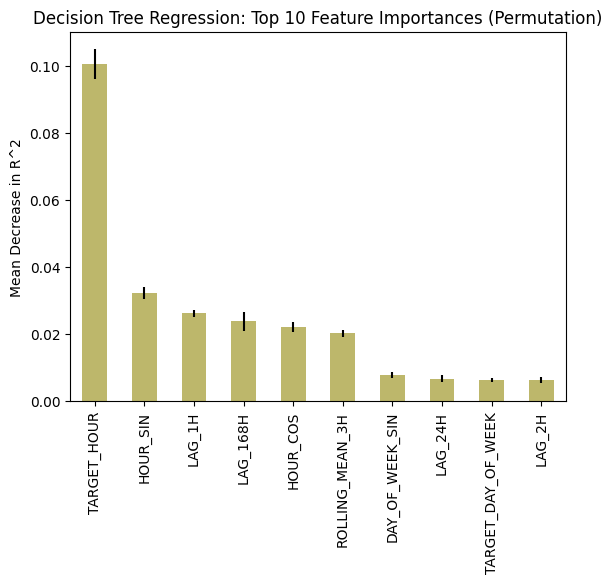

In [157]:
# Step 10: Create a feature importance table for Random Forest
feature_names = X_train.columns
result = permutation_importance(
    final_forest, X_val, y_val, scoring="r2", n_repeats=10, random_state=42, n_jobs=2
)

forest_importances = pd.Series(result.importances_mean, index=feature_names)
forest_std = pd.Series(result.importances_std, index=feature_names)
top10 = forest_importances.sort_values(ascending=False).head(10)

fig, ax = plt.subplots()
top10.plot.bar(yerr=forest_std[top10.index], ax=ax, color='darkkhaki')

ax.set_title("Decision Tree Regression: Top 10 Feature Importances (Permutation)")
ax.set_ylabel("Mean Decrease in R^2")
ax.yaxis.set_major_locator(plt.MaxNLocator(6))

save_figure("random_forest_feature_importance")